In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import get_peft_model, LoraConfig, TaskType
from torch.utils.data import DataLoader, Dataset
from torch.nn import functional as F
import json
import numpy as np
from tqdm import tqdm
from transformers import DataCollatorWithPadding
from accelerate import Accelerator
import matplotlib.pyplot as plt


/ssdscratch/byuan48/software/anaconda3/envs/reasoning_transformers/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# in the fine-tuned, following the format in instruction fine-tuning

class SentenceScoreDataset(Dataset):
    def __init__(self, sentences, scores, tokenizer, max_length):
        self.sentences = sentences
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_length,
            padding=False,  # No padding here
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.scores[idx], dtype=torch.float),
        }

# Replace the output layer with an MLP
class LlamaWithMLP(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.base_model = model
        self.hidden_size = model.config.hidden_size
        self.mlp_head = torch.nn.Sequential(
            torch.nn.Dropout(p=0.1),  
            torch.nn.Linear(self.hidden_size, 1),  
            torch.nn.Sigmoid(),  
        )
        # # Freeze the base model parameters
        # for param in self.base_model.parameters():
        #     param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
        hidden_states = outputs.hidden_states[-1]  # Last hidden state
        # pooled_output = hidden_states.mean(dim=1)  # Mean pooling be careful with padding
        pooled_output = hidden_states[:,-1,:]  # select the embedding of the last token
        score = self.mlp_head(pooled_output).squeeze(-1)
        return score


# Initialize model and tokenizer
model_name = "meta-llama/Llama-3.2-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left' # to prevent errors with FA
tokenizer.truncation_side = 'left' # to prevent cutting off last generation
device = torch.device("cuda:3")
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map=device)


# Set up LoRA configuration
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,  
    inference_mode=False,          
    r=2,                           
    lora_alpha=4,                  
    lora_dropout=0.2,              
)

base_model = get_peft_model(base_model, peft_config)
model = LlamaWithMLP(base_model)

Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.77s/it]


In [3]:
def count_trainable_parameters(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable_params

# Count trainable parameters
num_trainable_params = count_trainable_parameters(base_model)
print(f"Total trainable parameters: {num_trainable_params:,}")
num_trainable_params = count_trainable_parameters(model)
print(f"Total trainable parameters: {num_trainable_params:,}")
base_model.config.hidden_size

Total trainable parameters: 573,440
Total trainable parameters: 576,513


3072

In [4]:
# Prepare dataset
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            data.append(json.loads(line))
    return data


Starting Epoch 1/10...


Epoch 1/10: 100%|██████████| 2125/2125 [40:12<00:00,  1.14s/it]


Epoch 1/10 completed. Average Loss: 0.4694
Starting Epoch 2/10...


Epoch 2/10: 100%|██████████| 2125/2125 [40:26<00:00,  1.14s/it] 


Epoch 2/10 completed. Average Loss: 0.3175
Starting Epoch 3/10...


...

Epoch 8/10 completed. Average Loss: 0.1752
Starting Epoch 9/10...


Epoch 9/10: 100%|██████████| 2125/2125 [40:29<00:00,  1.14s/it]


Epoch 9/10 completed. Average Loss: 0.1717
Starting Epoch 10/10...


Epoch 10/10: 100%|██████████| 2125/2125 [40:21<00:00,  1.14s/it]


Epoch 10/10 completed. Average Loss: 0.1689
Fine-tuning completed and model saved!


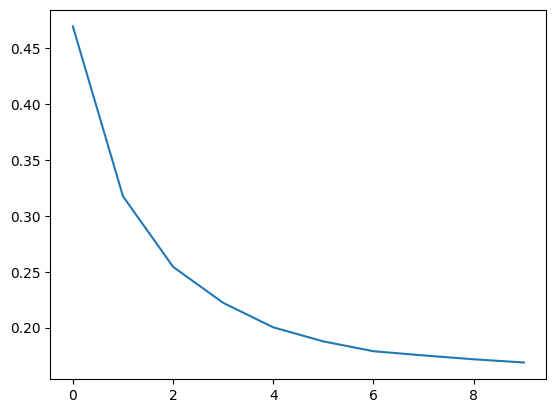

In [5]:
step1 = load_jsonl('/ssdscratch/byuan48/Reasoning/generated_datasets/train_filtered_dataset.jsonl')
sentences = [step1[i]['solution'] for i in range(len(step1))]
accuracies = np.array([step1[i]['accuracy'] for i in range(len(step1))])

sentences = sentences[:100]
accuracies = accuracies[:100]

dataset = SentenceScoreDataset(sentences, accuracies.flatten(order='C'), tokenizer, max_length=1024)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
dataloader = DataLoader(dataset, batch_size=4, collate_fn=data_collator,shuffle=True)

# Training setup
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = torch.nn.BCELoss()
model.to(device)

# Number of epochs
epochs = 10
losses = []

for epoch in range(epochs):
    model.train()  # Set model to training mode
    epoch_loss = 0  # Track total loss for the epoch

    print(f"Starting Epoch {epoch + 1}/{epochs}...")

    # Wrap the dataloader with tqdm for a progress bar
    for batch in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{epochs}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        predictions = model(input_ids, attention_mask)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()

        # Update epoch loss
        epoch_loss += loss.item()

    # Print epoch summary
    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch {epoch + 1}/{epochs} completed. Average Loss: {avg_loss:.4f}")

    # Save the model
    torch.save({
        'base_model_state_dict': model.base_model.state_dict(),
        'mlp_head_state_dict': model.mlp_head.state_dict()
    }, f"./llama3_lora_mlp/llama_with_mlp_{epoch}.pth")
    losses.append(avg_loss)
    
tokenizer.save_pretrained("./llama3_lora_mlp")

print("Fine-tuning completed and model saved!")
plt.plot(losses)


/tmp/ipykernel_4101812/390084536.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"./llama3_lora_mlp/llama_with_mlp_{epoch}.pth")
Inference: 100

Epoch 1 BCELoss: 0.3505


Inference: 100%|██████████| 175/175 [01:39<00:00,  1.75it/s]


Epoch 2 BCELoss: 0.3010


Inference: 100%|██████████| 175/175 [01:39<00:00,  1.76it/s]


...

Epoch 8 BCELoss: 0.2791


Inference: 100%|██████████| 175/175 [01:39<00:00,  1.75it/s]


Epoch 9 BCELoss: 0.2679


Inference: 100%|██████████| 175/175 [01:39<00:00,  1.76it/s]

Epoch 10 BCELoss: 0.2688


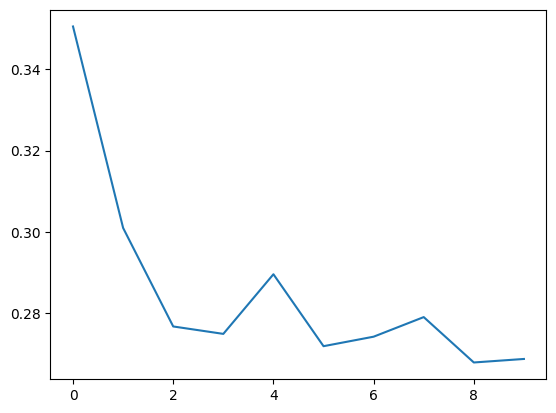

In [6]:
# inference
# Load the model
model = LlamaWithMLP(base_model)
step1 = load_jsonl('/ssdscratch/byuan48/Reasoning/generated_datasets/test_filtered_dataset.jsonl')
sentences = [step1[i]['solution'] for i in range(len(step1))]
accuracies = np.array([step1[i]['accuracy'] for i in range(len(step1))])
batch_size = 4
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("./llama3_lora_mlp")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left' 
tokenizer.truncation_side = 'left'

dataset = SentenceScoreDataset(sentences, accuracies.flatten(order='C'), tokenizer, max_length=1024)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=data_collator,shuffle=False)
losses = []

for epoch in range(epochs):
    checkpoint = torch.load(f"./llama3_lora_mlp/llama_with_mlp_{epoch}.pth")
    model.base_model.load_state_dict(checkpoint['base_model_state_dict'])
    model.mlp_head.load_state_dict(checkpoint['mlp_head_state_dict'])
    model.to(device)
    model.eval()
    # do inference
    predictions = []
    labels = []
    for batch in tqdm(dataloader, desc="Inference"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels.extend(batch["labels"].numpy())
        with torch.no_grad():
            output = model(input_ids, attention_mask)
        predictions.extend(output.cpu().numpy())
    new_predictions = torch.tensor(predictions,  dtype=torch.float)
    # compute the mse loss
    criterion = torch.nn.BCELoss()
    loss = criterion(new_predictions.reshape(1,-1), torch.tensor(accuracies,  dtype=torch.float).reshape(1,-1))
    print(f"Epoch {epoch + 1} BCELoss: {loss:.4f}")
    losses.append(loss.item())
plt.plot(losses)

In [4]:
import torch
from tqdm import tqdm
import numpy as np

def compare_lora_weights(model, previous_lora_weights):
    """Compare LoRA weights with the previously loaded weights."""
    current_lora_weights = {}
    for name, param in model.base_model.named_parameters():
        if "lora" in name:  # Filter for LoRA-specific parameters
            current_lora_weights[name] = param.detach().cpu().numpy()

    if previous_lora_weights is not None:
        for name, weight in current_lora_weights.items():
            if name in previous_lora_weights:
                is_different = not np.allclose(weight, previous_lora_weights[name], atol=1e-5)
                print(f"LoRA weight {name} is {'different' if is_different else 'identical'} compared to the previous checkpoint.")

    return current_lora_weights


# Initialize model
model = LlamaWithMLP(base_model)

# Placeholder for LoRA weights from the previous checkpoint
previous_lora_weights = None

for epoch in range(4):
    print(f"Loading model for epoch {epoch + 1}...")
    checkpoint = torch.load(f"./llama3_lora_mlp/llama_with_mlp_{epoch}.pth")
    model.base_model.load_state_dict(checkpoint['base_model_state_dict'])
    model.mlp_head.load_state_dict(checkpoint['mlp_head_state_dict'])
    model.to(device)
    model.eval()

    # Verify LoRA weights
    print(f"Verifying LoRA weights for epoch {epoch + 1}...")
    previous_lora_weights = compare_lora_weights(model, previous_lora_weights)

Loading model for epoch 1...


/tmp/ipykernel_626344/215403112.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"./llama3_lora_mlp/llama_with_mlp_{epoch}.pth")


Verifying LoRA weights for epoch 1...
Loading model for epoch 2...
Verifying LoRA weights for epoch 2...
LoRA weight base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight is different compared to the previous checkpoint.
LoRA weight base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight is different compared to the previous checkpoint.
LoRA weight base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight is different compared to the previous checkpoint.
LoRA weight base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight is different compared to the previous checkpoint.
LoRA weight base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight is different compared to the previous checkpoint.
LoRA weight base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight is different compared to the previous checkpoint.
LoRA weight base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight is different c